Title: capacity_data_all_plot.ipynb

Purpose: Plot the processed capacity data

Author: Onno Nennecke on 15.02.2025 Modified: 15.02.2025

Input data: 

    wind_offshore_power.nc, wind_onshore_power.nc, solar_power.nc
    - This file lies here: /climca/people/onennecke/Wind_Solar_MaStR/processed_data/

Output data:

    Plot?
    - This file lies here: 

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_power.nc')
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_power.nc')
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_power.nc')

In [3]:
grid_offshore['wind_off_cap'].sum()

<xarray.DataArray 'wind_off_cap' ()> Size: 8B
array(9215093.)
Coordinates:
    crs      int64 8B ...

In [11]:
grid_offshore_sum = grid_offshore['wind_off_cap'].sum() / 1000000
grid_onshore_sum = grid_onshore['wind_on_cap'].sum() / 1000000
grid_solar_sum = grid_solar['solar_cap'].sum() / 1000000

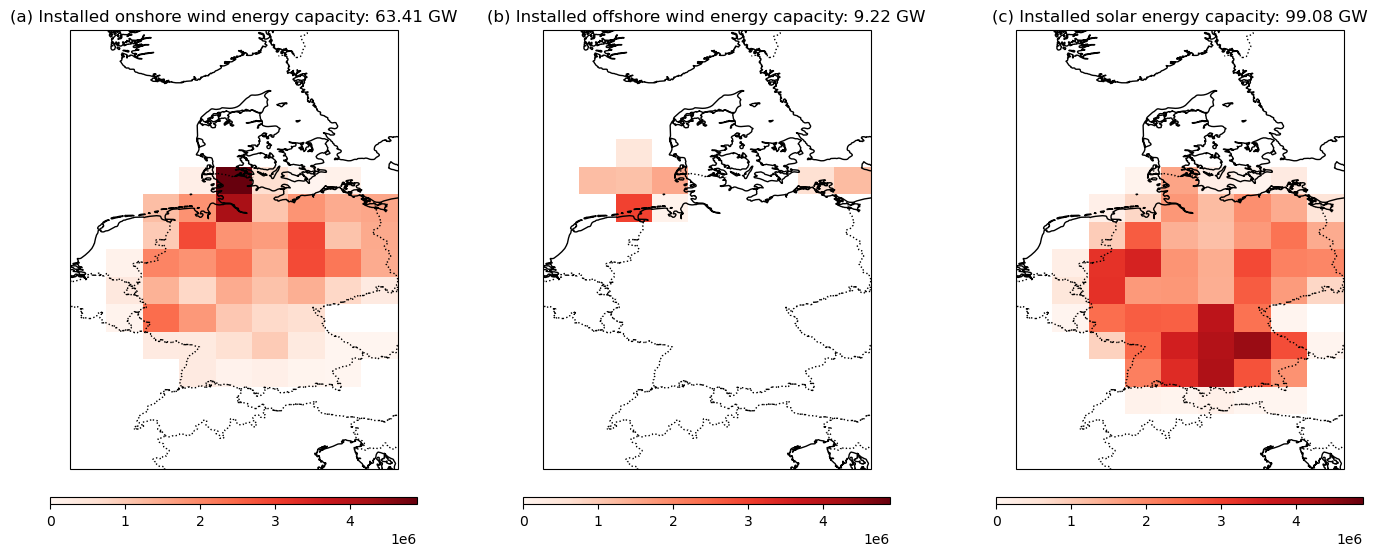

In [15]:
lon_edges = grid_offshore.lon.values - (grid_offshore.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid_offshore.lat.values - (grid_offshore.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

xxx1 = grid_onshore['wind_on_cap']
xxx2 = grid_offshore['wind_off_cap']
xxx3 = grid_solar['solar_cap']

# Determine the common colorbar range
vmin = 0 # min(xxx1.min(), xxx2.min(), xxx3.min())
vmax = max(xxx1.max(), xxx2.max(), xxx3.max())

# Plot the data with common colorbar range
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title(f'(a) Installed onshore wind energy capacity: {grid_onshore_sum.values:.2f} GW')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title(f'(b) Installed offshore wind energy capacity: {grid_offshore_sum.values:.2f} GW')

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im3 = ax3.pcolormesh(lon_edges, lat_edges, xxx3, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax3.set_title(f'(c) Installed solar energy capacity: {grid_solar_sum.values:.2f} GW')

# Add a single colorbar for all subplots
# cbar = fig.colorbar(im3, ax=[ax1, ax2, ax3], orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
# cbar.set_label('Capacity')

plt.tight_layout()
plt.show()